In [25]:
# If needed in Colab, uncomment:
#!pip install numpy scipy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from scipy.optimize import minimize_scalar

plt.rcParams['figure.dpi'] = 140
np.set_printoptions(precision=6, suppress=True)


In [26]:
# -----------------------------
# Physical and dimensionless parameters
# -----------------------------
l = 1
n0 = 14
a = 29e-3 * 1/4             # aperture radius [m]
lam = 633e-9          # wavelength [m]
k = 2 * np.pi / lam   # optical wavenumber [1/m]

tau_f = 1.0 / (2 * np.pi * n0)
z_f = k * a**2 * tau_f

print(f'tau_f = {tau_f:.9f}')
print(f'z_f   = {z_f:.6f} m')


tau_f = 0.011368210
z_f   = 5.931223 m


In [27]:
# Integration grid for beta optimization
rho_beta = np.linspace(0.0, 1.0, 40001)

def I0_of_beta(beta):
    J = jv(l, beta * rho_beta)
    return np.trapz(rho_beta * J**2, rho_beta) / (2 * np.pi)

def R_of_beta(beta):
    J = jv(l, beta * rho_beta)
    phase = np.exp(1j * rho_beta**2 / tau_f)
    return np.trapz(rho_beta * J**2 * phase, rho_beta) / (2 * np.pi)

def lambda_plus(beta):
    I0 = I0_of_beta(beta)
    R = R_of_beta(beta)
    return (I0 + np.abs(R)) / (2 * tau_f**2)

# Adjust the search interval if you want to explore more peaks.
opt = minimize_scalar(lambda b: -lambda_plus(b), bounds=(1e-4, 20.0), method='bounded', options={'xatol': 1e-6})
beta_opt = float(opt.x)
lambda_opt = float(lambda_plus(beta_opt))

print(f'beta_opt   = {beta_opt:.9f}')
print(f'lambda_opt = {lambda_opt:.9f}')


beta_opt   = 2.391468288
lambda_opt = 83.926160274


/tmp/ipykernel_11390/1277079169.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(rho_beta * J**2, rho_beta) / (2 * np.pi)
/tmp/ipykernel_11390/1277079169.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(rho_beta * J**2 * phase, rho_beta) / (2 * np.pi)


In [28]:
# ============================================================
# Build the three masks: optimal, PFBZ, FBZ
# all normalized numerically with
# 2π ∫_0^1 rho |psi(rho)|^2 d rho = 1
# ============================================================

Nrho_in = 4000
rho_in = np.linspace(0.0, 1.0, Nrho_in)

J_beta = jv(l, beta_opt * rho_in)

I0_beta = np.trapz(rho_in * J_beta**2, rho_in) / (2 * np.pi)
R_beta = np.trapz(
    rho_in * J_beta**2 * np.exp(1j * rho_in**2 / tau_f),
    rho_in
) / (2 * np.pi)

theta = 0.5 * np.angle(R_beta)
phase_arg = rho_in**2 / (2 * tau_f) - theta

def normalize_pupil(psi_raw, rho):
    norm = np.sqrt(2 * np.pi * np.trapz(rho * np.abs(psi_raw)**2, rho))
    psi = psi_raw / norm
    norm_check = 2 * np.pi * np.trapz(rho * np.abs(psi)**2, rho)
    return psi, norm_check

# Optimal
psi_opt_raw = J_beta * np.cos(phase_arg)
psi_opt, norm_opt = normalize_pupil(psi_opt_raw, rho_in)

# PFBZ
# Use a strict ±1 convention rather than np.sign(...) so exact zeros do not
# appear as isolated 0-valued pixels at sampled nodal radii.
expr_pfbz = J_beta * np.cos(phase_arg)
psi_pfbz_raw = (2 * np.sqrt(np.pi)) * np.where(expr_pfbz >= 0.0, 1.0, -1.0)
psi_pfbz, norm_pfbz = normalize_pupil(psi_pfbz_raw, rho_in)

# FBZ
expr_fbz = np.cos(phase_arg)
psi_fbz_raw = (J_beta / np.sqrt(I0_beta)) * np.where(expr_fbz >= 0.0, 1.0, -1.0)
psi_fbz, norm_fbz = normalize_pupil(psi_fbz_raw, rho_in)

rho_star = beta_opt * tau_f
r_star = a * rho_star

print(f'theta       = {theta:.9f} rad')
print(f'rho_star    = {rho_star:.9f}')
print(f'r_star      = {1e3 * r_star:.6f} mm')
print(f'I0(betaopt) = {I0_beta:.9f}')
print()
print(f'opt  norm check  = {norm_opt:.12f}')
print(f'PFBZ norm check  = {norm_pfbz:.12f}')
print(f'FBZ  norm check  = {norm_fbz:.12f}')
# Mask descriptors for bounded visualization (not for propagation)
mask_pfbz_sign = np.sign(J_beta * np.cos(phase_arg))
mask_fbz_sign  = np.sign(np.cos(phase_arg))
mask_pfbz_amp = mask_pfbz_sign.astype(float)
mask_fbz_amp_raw = J_beta * mask_fbz_sign
mask_fbz_amp = mask_fbz_amp_raw / np.max(np.abs(mask_fbz_amp_raw))


theta       = -0.820722728 rad
rho_star    = 0.027186714
r_star      = 0.197104 mm
I0(betaopt) = 0.021445926

opt  norm check  = 1.000000000000
PFBZ norm check  = 1.000000000000
FBZ  norm check  = 1.000000000000


/tmp/ipykernel_11390/2775560368.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I0_beta = np.trapz(rho_in * J_beta**2, rho_in) / (2 * np.pi)
/tmp/ipykernel_11390/2775560368.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  R_beta = np.trapz(
/tmp/ipykernel_11390/2775560368.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(2 * np.pi * np.trapz(rho * np.abs(psi_raw)**2, rho))
/tmp/ipykernel_11390/2775560368.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_check = 2 * np.pi * np.trapz(rho * np.abs(psi)**2, rho)


In [29]:
def plot_pupil_intensity_2d(psi_radial, rho_in, title):
    N = 800
    x = np.linspace(-1.0, 1.0, N)
    y = np.linspace(-1.0, 1.0, N)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    psi_2d = np.interp(R, rho_in, psi_radial, left=0.0, right=0.0)
    I_2d = np.abs(psi_2d)**2
    I_masked = np.ma.masked_where(R > 1.0, I_2d)

    fig, ax = plt.subplots(figsize=(5.2, 5.2))

    cmap = plt.cm.cividis.copy()
    cmap.set_bad(color='#2f5d95')

    im = ax.imshow(
        I_masked,
        origin='lower',
        extent=[-1, 1, -1, 1],
        cmap=cmap,
        interpolation='bilinear',
        vmin=0,
        vmax=1
    )

    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    cbar = plt.colorbar(
        im,
        ax=ax,
        label=r'$|\psi(\rho)|^2$',
        fraction=0.046,
        pad=0.04,
        shrink=0.82
    )
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['0', '0.5', '1'])

    plt.tight_layout()
    plt.show()


def propagate_mask(psi_radial, rho_in, rho_out, taus, l):
    intensity_tau_rho = np.zeros((len(taus), len(rho_out)), dtype=float)

    initial_amp = np.interp(rho_out, rho_in, psi_radial)
    intensity_tau_rho[0, :] = np.abs(initial_amp)**2

    rho_prime = rho_in[None, :]
    psi_row = psi_radial[None, :]
    rho_col = rho_out[:, None]

    for j, tau in enumerate(taus[1:], start=1):
        phase_in = np.exp(1j * rho_prime**2 / (2 * tau))
        bessel = jv(l, rho_col * rho_prime / tau)
        integrand = rho_prime * phase_in * bessel * psi_row
        radial_int = np.trapz(integrand, rho_in, axis=1)
        amp = ((-1j)**l) / (1j * tau) * np.exp(1j * rho_out**2 / (2 * tau)) * radial_int
        intensity_tau_rho[j, :] = np.abs(amp)**2

    intensity_tau_rho /= intensity_tau_rho.max()
    return intensity_tau_rho


def plot_x_tau(intensity_tau_rho, rho_out, taus, a, k, tau_f, title):
    Nx = 900
    x_out = np.linspace(-1.0, 1.0, Nx)
    x_mm = 1e3 * a * x_out

    intensity_x = np.zeros((len(taus), len(x_out)))
    for j in range(len(taus)):
        intensity_x[j, :] = np.interp(np.abs(x_out), rho_out, intensity_tau_rho[j, :])

    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    im = ax.imshow(
        intensity_x.T,
        origin='lower',
        aspect='auto',
        extent=[taus[0], taus[-1], x_mm[0], x_mm[-1]],
        interpolation='nearest',
        cmap='viridis'
    )

    ax.set_xlabel(r'$\tau$')
    ax.set_ylabel('x [mm]')
    ax.set_title(title)

    ax.axvline(tau_f, color='w', ls='--', lw=1.1, alpha=0.9, label=r'$\tau_f$')
    ax.legend(loc='upper right', framealpha=0.9)

    secax = ax.secondary_xaxis(
        'top',
        functions=(lambda tau: k * a**2 * tau, lambda z: z / (k * a**2))
    )
    secax.set_xlabel('propagation distance z [m]')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('normalized intensity')

    plt.tight_layout()
    plt.show()


def _radial_spec_to_2d(spec, rho_in, R):
    """
    Convert either a sampled radial array or a callable radial specification
    into a 2D array on the radius grid R.
    """
    if callable(spec):
        return spec(R)
    return np.interp(R, rho_in, np.asarray(spec), left=0.0, right=0.0)


def plot_mask_amplitude_2d(mask_spec, rho_in, title):
    """
    Plot a real-valued pupil-plane mask amplitude with a fixed color scale
    in the interval [-1, 1].

    If mask_spec is callable, it is evaluated directly on the 2D radius grid.
    This avoids interpolation artifacts for binary masks.
    """
    N = 800
    x = np.linspace(-1.0, 1.0, N)
    y = np.linspace(-1.0, 1.0, N)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    amp_2d = _radial_spec_to_2d(mask_spec, rho_in, R)
    amp_2d = np.clip(amp_2d, -1.0, 1.0)
    amp_masked = np.ma.masked_where(R > 1.0, amp_2d)

    fig, ax = plt.subplots(figsize=(5.2, 5.2))

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='white')

    im = ax.imshow(
        amp_masked,
        origin='lower',
        extent=[-1, 1, -1, 1],
        cmap=cmap,
        interpolation='nearest',
        vmin=-1.0,
        vmax=1.0
    )

    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    cbar = plt.colorbar(
        im,
        ax=ax,
        label='mask amplitude',
        fraction=0.046,
        pad=0.04,
        shrink=0.82
    )
    cbar.set_ticks([-1, 0, 1])
    cbar.set_ticklabels(['-1', '0', '1'])

    plt.tight_layout()
    plt.show()


def plot_binary_phase_pi_2d(mask_sign_spec, rho_in, title):
    """
    Plot the binary phase associated with a sign mask, using values in
    {-π, +π}. If mask_sign_spec is callable, it is evaluated directly on the
    2D radius grid to avoid interpolation artifacts.
    """
    N = 800
    x = np.linspace(-1.0, 1.0, N)
    y = np.linspace(-1.0, 1.0, N)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    sign_2d = _radial_spec_to_2d(mask_sign_spec, rho_in, R)
    sign_2d = np.where(sign_2d >= 0.0, 1.0, -1.0)
    phase_masked = np.ma.masked_where(R > 1.0, np.pi * sign_2d)

    fig, ax = plt.subplots(figsize=(5.2, 5.2))

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='white')

    im = ax.imshow(
        phase_masked,
        origin='lower',
        extent=[-1, 1, -1, 1],
        cmap=cmap,
        interpolation='nearest',
        vmin=-np.pi,
        vmax=np.pi
    )

    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    cbar = plt.colorbar(
        im,
        ax=ax,
        label='phase [rad]',
        fraction=0.046,
        pad=0.04,
        shrink=0.82
    )
    cbar.set_ticks([-np.pi, 0, np.pi])
    cbar.set_ticklabels([r'$-\pi$', '0', r'$\pi$'])

    plt.tight_layout()
    plt.show()


In [30]:
# ------------------------------------------------------------
# Mask descriptors used for visualization only.
# These are NOT the L2-normalized pupil fields used for propagation.
#
# For plotting, use callable radial specifications evaluated directly on the
# 2D radius grid. This avoids interpolation artifacts such as isolated dots
# on sharp binary rings.
# ------------------------------------------------------------
def _binary_pm_one(expr):
    return np.where(expr >= 0.0, 1.0, -1.0)

J_beta_max = np.max(np.abs(J_beta))

def mask_pfbz_sign_func(r):
    return _binary_pm_one(jv(l, beta_opt * r) * np.cos(r**2 / (2 * tau_f) - theta))

def mask_fbz_sign_func(r):
    return _binary_pm_one(np.cos(r**2 / (2 * tau_f) - theta))

def mask_opt_sign_func(r):
    return _binary_pm_one(jv(l, beta_opt * r) * np.cos(r**2 / (2 * tau_f) - theta))

def mask_pfbz_amp_func(r):
    return mask_pfbz_sign_func(r)

def mask_fbz_amp_func(r):
    return jv(l, beta_opt * r) * mask_fbz_sign_func(r) / J_beta_max

mask_pfbz_sign = mask_pfbz_sign_func(rho_in)
mask_fbz_sign  = mask_fbz_sign_func(rho_in)
mask_opt_sign  = mask_opt_sign_func(rho_in)

mask_pfbz_amp = mask_pfbz_amp_func(rho_in)
mask_fbz_amp  = mask_fbz_amp_func(rho_in)


In [31]:
Ntau = 320
Nrho_out = 700

tau_max = 2.0 * tau_f
taus = np.concatenate(([0.0], np.linspace(tau_f / 250, tau_max, Ntau - 1)))
rho_out = np.linspace(0.0, 1.0, Nrho_out)

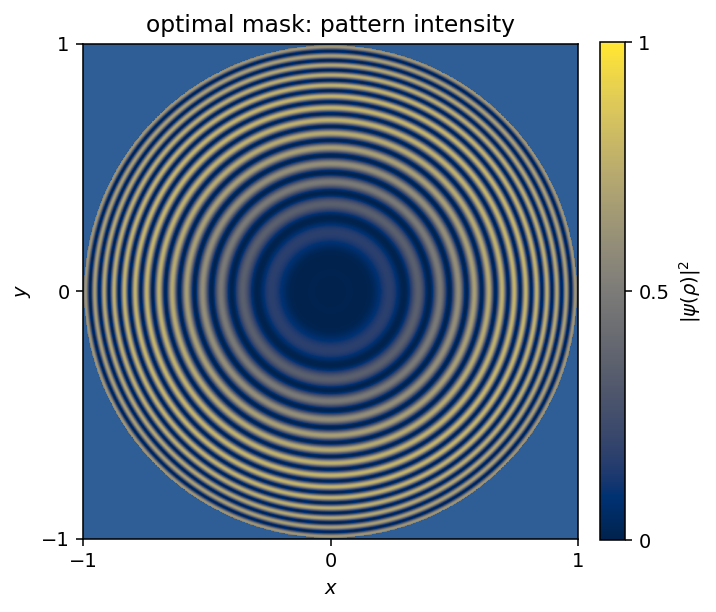

/tmp/ipykernel_11390/3538463614.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  radial_int = np.trapz(integrand, rho_in, axis=1)


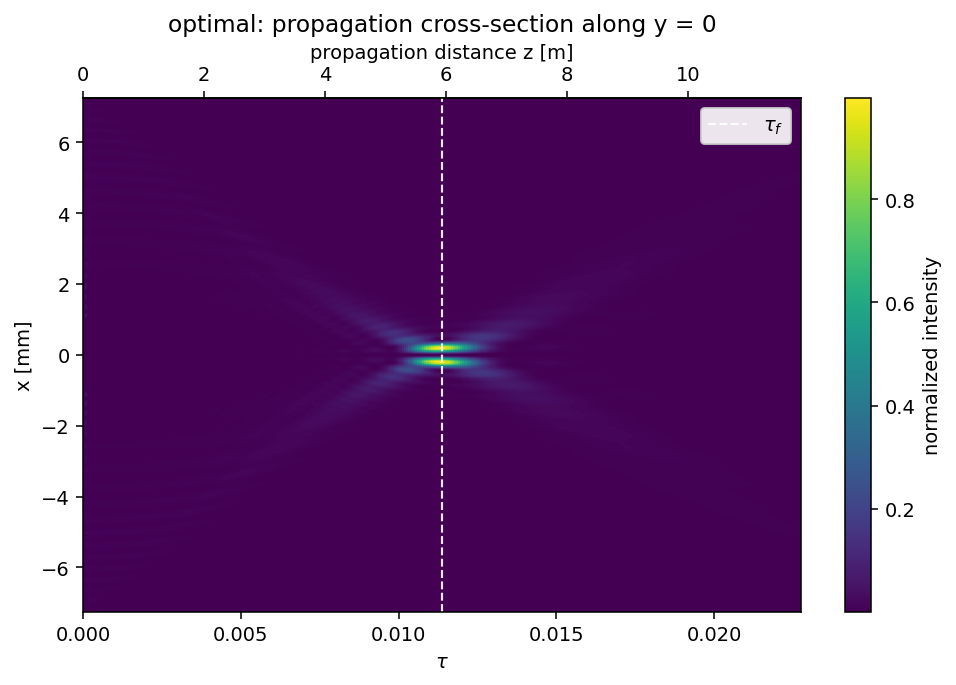

In [32]:
# Optimal mask: keep the pupil-plane INTENSITY plot exactly as in the original code,
# then show the propagation intensity cross-section.
# Only the PFBZ and FBZ pupil-plane visualizations were changed to bounded mask plots.
psi_current = psi_opt
name = "optimal"

plot_pupil_intensity_2d(psi_current, rho_in, f'{name} mask: pattern intensity')
intensity_tau_rho = propagate_mask(psi_current, rho_in, rho_out, taus, l)
plot_x_tau(
    intensity_tau_rho,
    rho_out,
    taus,
    a,
    k,
    tau_f,
    f'{name}: propagation cross-section along y = 0'
)

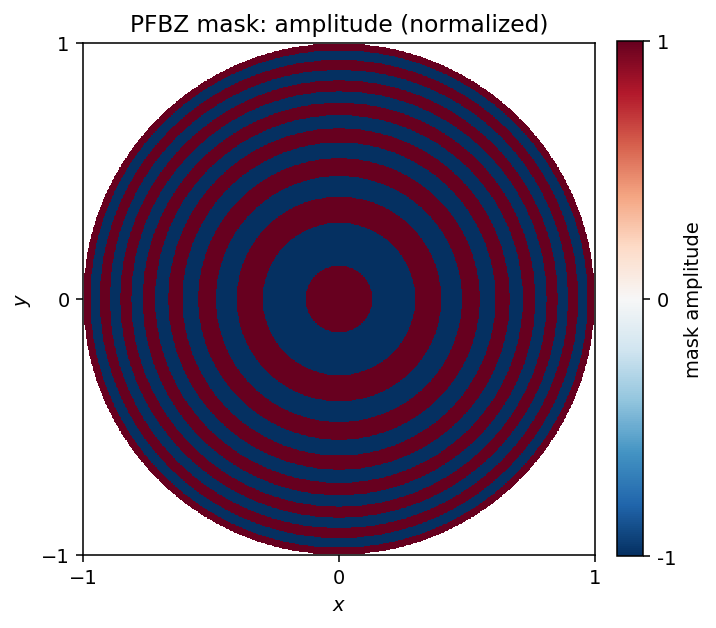

/tmp/ipykernel_11390/3538463614.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  radial_int = np.trapz(integrand, rho_in, axis=1)


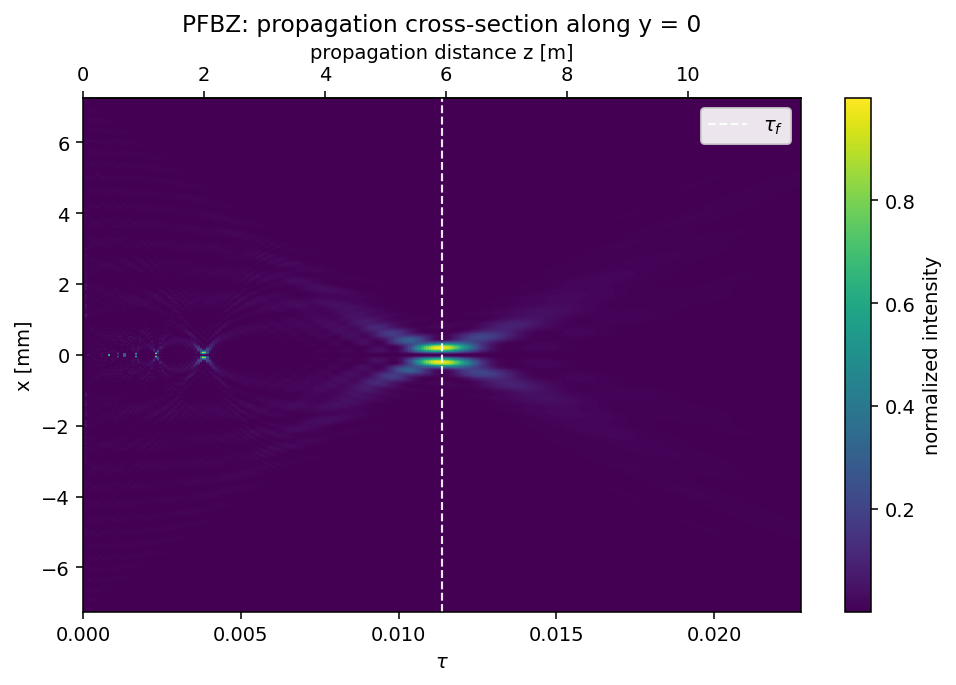

In [33]:
# Helper functions already defined above.
# PFBZ: show mask amplitude in the pupil plane (bounded in [-1,1]),
# then keep the propagation intensity cross-section as before.
psi_current = psi_pfbz
name = "PFBZ"

plot_mask_amplitude_2d(mask_pfbz_amp_func, rho_in, f'{name} mask: amplitude (normalized)')
intensity_tau_rho = propagate_mask(psi_current, rho_in, rho_out, taus, l)
plot_x_tau(
    intensity_tau_rho,
    rho_out,
    taus,
    a,
    k,
    tau_f,
    f'{name}: propagation cross-section along y = 0'
)


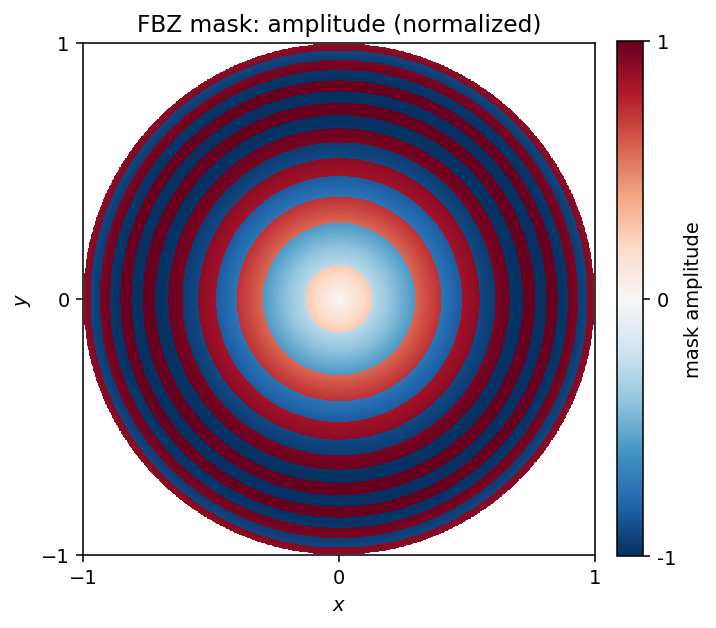

/tmp/ipykernel_11390/3538463614.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  radial_int = np.trapz(integrand, rho_in, axis=1)


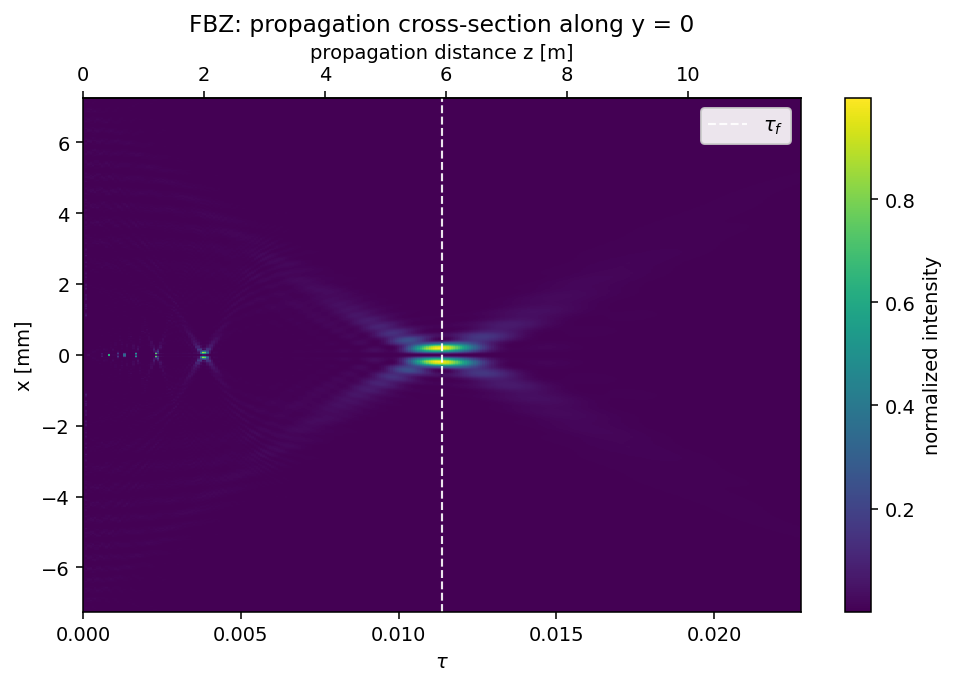

In [34]:
# Helper functions already defined above.
# FBZ: show mask amplitude in the pupil plane (bounded in [-1,1]),
# then keep the propagation intensity cross-section as before.
psi_current = psi_fbz
name = "FBZ"

plot_mask_amplitude_2d(mask_fbz_amp_func, rho_in, f'{name} mask: amplitude (normalized)')
intensity_tau_rho = propagate_mask(psi_current, rho_in, rho_out, taus, l)
plot_x_tau(
    intensity_tau_rho,
    rho_out,
    taus,
    a,
    k,
    tau_f,
    f'{name}: propagation cross-section along y = 0'
)


Helper plotting functions for bounded mask amplitude / phase were moved earlier in the notebook so later cells run in top-to-bottom order without `NameError`.


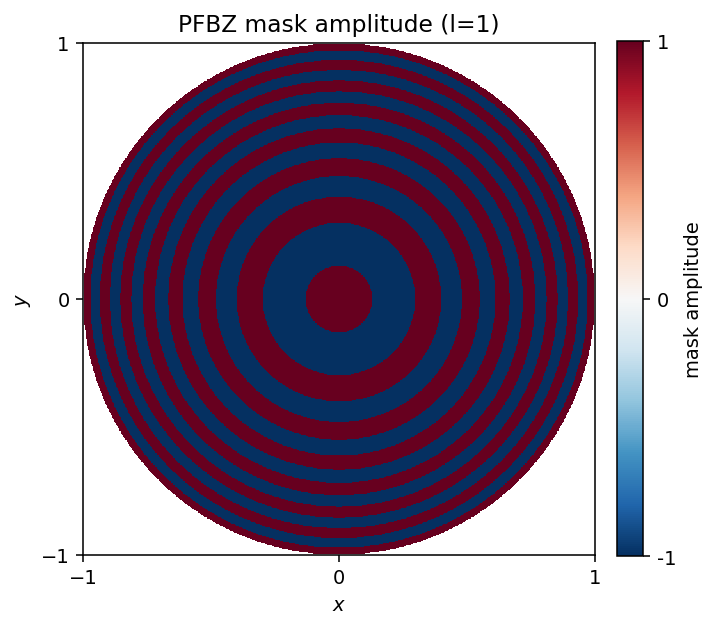

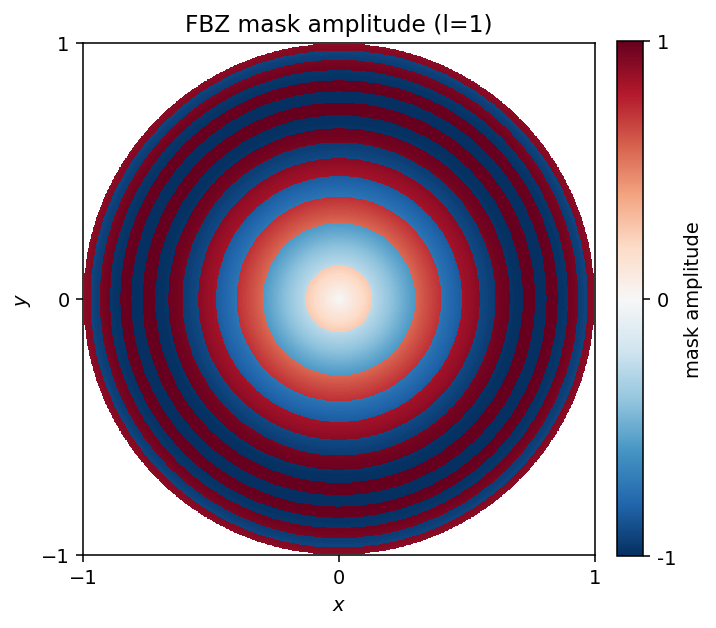

In [35]:
# Bounded pupil-plane mask amplitudes
plot_mask_amplitude_2d(mask_pfbz_amp_func, rho_in, f'PFBZ mask amplitude (l={l})')
plot_mask_amplitude_2d(mask_fbz_amp_func,  rho_in, f'FBZ mask amplitude (l={l})')


In [36]:
print('PFBZ mask amplitude range:', np.min(mask_pfbz_amp), np.max(mask_pfbz_amp))
print('FBZ  mask amplitude range:', np.min(mask_fbz_amp), np.max(mask_fbz_amp))
print('PFBZ binary phase range  :', np.min(np.pi * mask_pfbz_sign), np.max(np.pi * mask_pfbz_sign))
print('FBZ  binary phase range  :', np.min(np.pi * mask_fbz_sign), np.max(np.pi * mask_fbz_sign))


PFBZ mask amplitude range: -1.0 1.0
FBZ  mask amplitude range: -1.0 0.9999823958749544
PFBZ binary phase range  : -3.141592653589793 3.141592653589793
FBZ  binary phase range  : -3.141592653589793 3.141592653589793


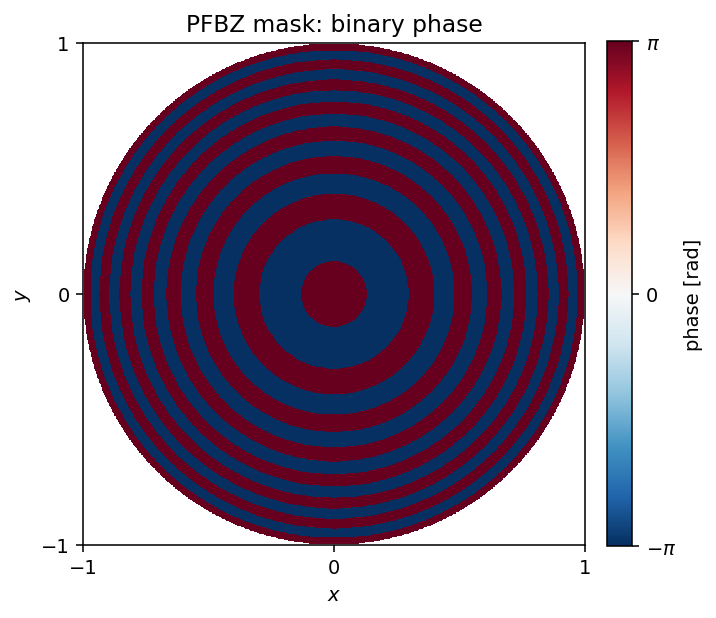

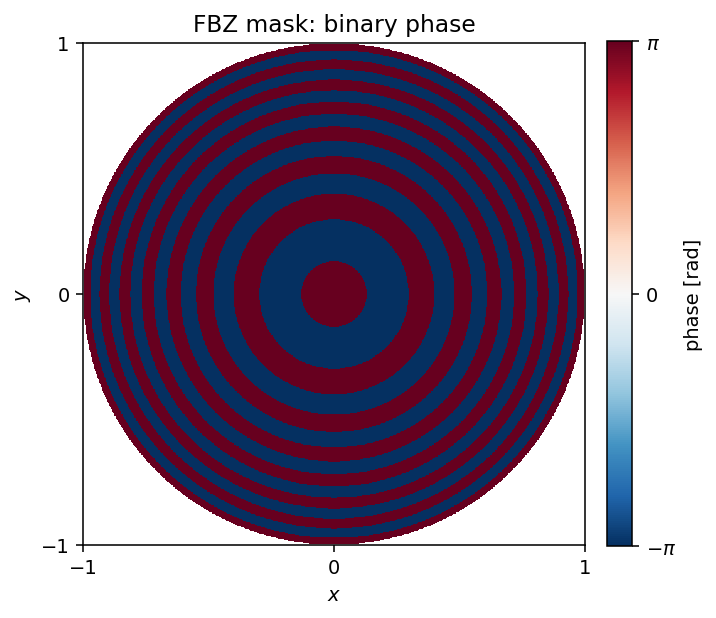

In [37]:
plot_binary_phase_pi_2d(mask_pfbz_sign_func, rho_in, 'PFBZ mask: binary phase')
plot_binary_phase_pi_2d(mask_fbz_sign_func,  rho_in, 'FBZ mask: binary phase')


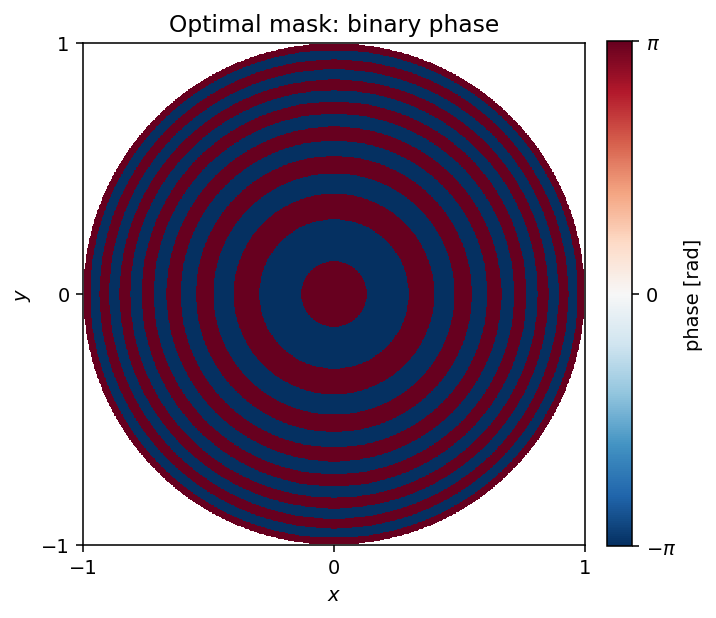

In [38]:
plot_binary_phase_pi_2d(mask_opt_sign_func, rho_in, 'Optimal mask: binary phase')


**Note.** In this notebook, the **optimal mask** still uses the original pupil-plane **intensity** plot and propagation intensity plot. Only the **PFBZ** and **FBZ** pupil-plane visualizations were changed to bounded **mask amplitude / binary phase** plots for display purposes.